ARTI308 - Machine Learning

## Lab 4: Data Quality Assessment & Preprocessing

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

## Step 1: Load Dataset

In [2]:
df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Step 2: Identify Data Quality Issues

In [4]:
# Check data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
# Check missing values
df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [6]:
# Check duplicates
df.duplicated().sum()

np.int64(0)

In [7]:
# Summary statistics
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


The dataset was checked for missing values, duplicate records, and data types to ensure data quality before preprocessing.

## Step 3: Handle Missing Values

In [9]:
# Fill missing values using mean 
df.fillna(df.mean(numeric_only=True), inplace=True)
The dataset was examined for missing values. The results showed that there were no missing values, so no imputation was required.
df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

The dataset was examined for missing values. The results showed that there were no missing values, so no imputation was required.

## Step 4: Detect and Handle Outliers using IQR

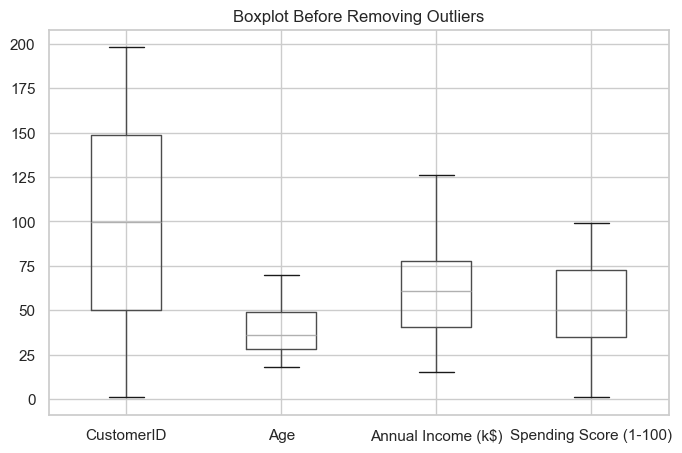

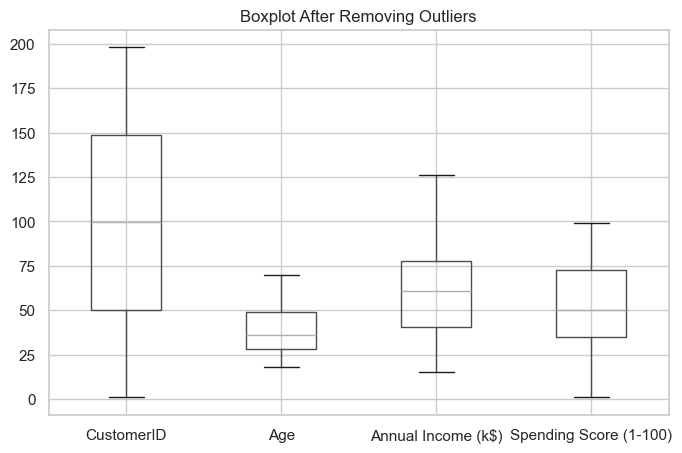

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [29]:
# Detect and Handle Outliers using IQR

numeric_df = df.select_dtypes(include='number')

# Boxplot BEFORE removing outliers
plt.figure(figsize=(8,5))
numeric_df.boxplot()
plt.title("Boxplot Before Removing Outliers")
plt.show()

# IQR calculation
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Remove outliers
df = df[~((numeric_df < lower) | (numeric_df > upper)).any(axis=1)]

# Boxplot AFTER removing outliers
numeric_df_after = df.select_dtypes(include='number')

plt.figure(figsize=(8,5))
numeric_df_after.boxplot()
plt.title("Boxplot After Removing Outliers")
plt.show()

df.head()

Outliers were detected and removed using the Interquartile Range (IQR) method to improve the consistency and reliability of the dataset.
Boxplots were used to visualize the distribution of numerical features before and after removing outliers. The plots appear similar because the dataset contained only a small number of extreme values.

## Step 5: Normalization (Min-Max and Z-score)

In [20]:
numeric_df = df.select_dtypes(include='number')
numeric_df.head()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,2,21,15,81
2,3,20,16,6
3,4,23,16,77
4,5,31,17,40


In [22]:
# Min-Max Normalization
from sklearn.preprocessing import MinMaxScaler

minmax = MinMaxScaler()

df_minmax = pd.DataFrame(
    minmax.fit_transform(numeric_df),
    columns=numeric_df.columns
)

df_minmax.head()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
0,0.000000,0.019231,0.000000,0.387755
1,0.005076,0.057692,0.000000,0.816327
2,0.010152,0.038462,0.009009,0.051020
3,0.015228,0.096154,0.009009,0.775510
4,0.020305,0.250000,0.018018,0.397959


In [23]:
# Z-score Normalization
from sklearn.preprocessing import StandardScaler

zscore = StandardScaler()

df_zscore = pd.DataFrame(
    zscore.fit_transform(numeric_df),
    columns=numeric_df.columns
)

df_zscore.head()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
0,-1.723325,-1.425414,-1.779171,-0.435989
1,-1.705829,-1.282367,-1.779171,1.199413
2,-1.688334,-1.353890,-1.739447,-1.720949
3,-1.670838,-1.139319,-1.739447,1.043661
4,-1.653342,-0.567131,-1.699723,-0.397051


Numerical features such as Age, Annual Income, and Spending Score were normalized using both Min-Max scaling and Z-score standardization. This ensured that all features were placed on a similar scale and prepared the dataset for further analysis.

## Step 6: Check Correlation

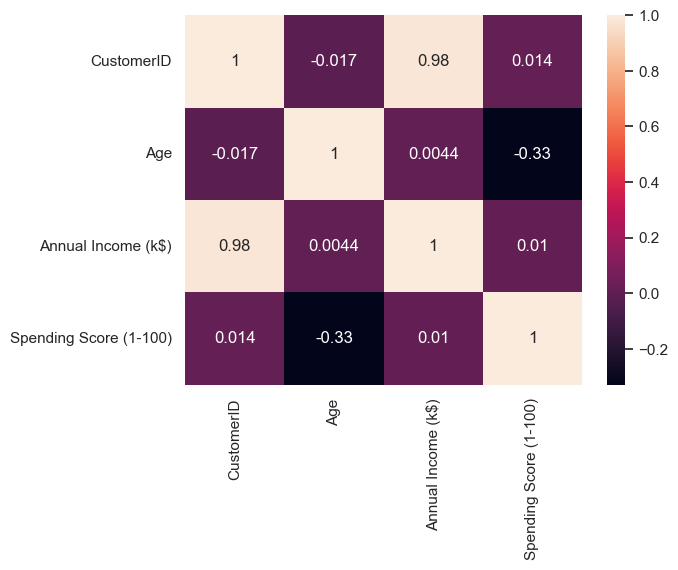

In [24]:
corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix, annot=True)
plt.show()

A correlation heatmap was generated to examine relationships between numerical features. The results showed a strong correlation between CustomerID and Annual Income, while other features showed weak or moderate relationships.

## Step 7: Apply PCA

In [27]:
# Remove ID column before PCA
numeric_df = numeric_df.drop(columns=["CustomerID"])
numeric_df.head()

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_result = pca.fit_transform(numeric_df)

pca_result[:5]
pca.explained_variance_ratio_

array([0.4625484 , 0.42524169])

Principal Component Analysis (PCA) was applied because some correlation was observed between numerical features. The CustomerID column was removed before applying PCA since it represents an identifier rather than a meaningful feature. PCA helped reduce the dimensionality of the dataset while preserving important information.